In [1]:
# ====================================================
# 完全にゼロから構築するハバードモデル近似状態(MPS)生成コード
# ====================================================
import Pkg
# 既存の壊れた環境を回避するため、専用のクリーンな環境を作って最新版を入れます
Pkg.activate("Hubbard_MPS_Env")
Pkg.add("ITensors")

using ITensors
using LinearAlgebra
using Printf

# --- 1. ハミルトニアン(MPO)の構築 ---
function build_hubbard_mpo(sites, t_L, t_S, U, mu)
    os = OpSum() # 最新版のITensorsなので確実にOpSumが使えます

    # ホッピング項 (Jordan-Wigner変換によるZ文字列を含む)
    function add_hopping!(os, i, j, t)
        min_idx, max_idx = min(i, j), max(i, j)
        
        # c_max^dagger c_min
        term1 = Any[-t, "S-", max_idx]
        for k in (min_idx+1):(max_idx-1); push!(term1, "Z", k); end
        push!(term1, "S+", min_idx)
        os += tuple(term1...)

        # c_min^dagger c_max
        term2 = Any[-t, "S+", max_idx]
        for k in (min_idx+1):(max_idx-1); push!(term2, "Z", k); end
        push!(term2, "S-", min_idx)
        os += tuple(term2...)
    end

    # 結合の定義
    edges_L = [(1, 3), (2, 4), (5, 7), (6, 8), (1, 7), (2, 8)]
    for (i, j) in edges_L; add_hopping!(os, i, j, t_L); end

    edges_S = [(3, 5), (4, 6)]
    for (i, j) in edges_S; add_hopping!(os, i, j, t_S); end

    # オンサイト反発 U (S-_i S+_i = n_i)
    for i in 1:2:7
        j = i + 1
        os += U, "S-", i, "S+", i, "S-", j, "S+", j
    end

    # 化学ポテンシャル mu
    for i in 1:8
        os += -mu, "S-", i, "S+", i
    end

    return MPO(os, sites)
end

# --- 2. DMRGによる状態生成 ---
function get_mps_state(H_mpo, sites, max_chi::Int)
    # ランダムな初期状態
    psi0 = randomMPS(sites, linkdims=2)

    # DMRGの設定 (maxdimでボンド次元=近似の画質を制御)
    nsweeps = 8
    maxdim = [10, 20, max_chi, max_chi]
    cutoff = 1E-10

    # outputlevel=1 にして、DMRGが動いている様子を見えるようにします
    energy, psi_mps = dmrg(H_mpo, psi0; nsweeps, maxdim, cutoff, outputlevel=1)

    # 後でShadowコードで使えるように、256次元ベクトルに変換して規格化
    vec_multi = Array(prod(psi_mps), sites...)
    vec_out = reshape(vec_multi, 256)
    vec_out ./= norm(vec_out)
    return real.(vec_out)
end

# --- 3. メインテスト実行部 ---
function main()
    println("\n=== テンソルネットワーク(MPS)による基底状態生成テスト ===")

    # パラメータ
    t_L, t_S = 1.0, 1.0
    U = 4.0
    mu = U / 2.0

    # サイトの定義
    sites = siteinds("S=1/2", 8)

    # ハミルトニアンの構築
    println("\n[1/3] ハミルトニアン(MPO)を構築中...")
    H_mpo = build_hubbard_mpo(sites, t_L, t_S, U, mu)

    # 真の基底状態 (高ボンド次元)
    println("\n[2/3] 真の基底状態を計算中 (ボンド次元上限=100) ...")
    vec_true = get_mps_state(H_mpo, sites, 100)

    # 近似状態・Prior (低ボンド次元)
    chi = 4
    println("\n[3/3] 近似状態(Prior)を計算中 (ボンド次元上限=$chi) ...")
    vec_approx = get_mps_state(H_mpo, sites, chi)

    # 結果の確認 (フィデリティ)
    fidelity = abs(dot(vec_true, vec_approx))^2
    println("\n=========================================================")
    @printf("  [大成功!] MPS Prior Fidelity (χ=%d): %.4f\n", chi, fidelity)
    println("=========================================================")
end

# 実行
main()

  Activating new project at `~/RandomMeas.jl/examples/tatsuyama/Hubbard_MPS_Env`
    Updating registry at `~/.julia/registries/General.toml`
   Resolving package versions...
   Installed SciMLPublic ────────── v1.0.1
   Installed Dictionaries ───────── v0.4.6
   Installed EllipsisNotation ───── v1.9.0
   Installed Adapt ──────────────── v4.5.2
   Installed Zeros ──────────────── v0.4.1
   Installed Accessors ──────────── v0.1.44
   Installed Preferences ────────── v1.5.2
   Installed FillArrays ─────────── v1.16.0
   Installed StaticArrays ───────── v1.9.18
   Installed BitIntegers ────────── v0.3.7
   Installed StridedViews ───────── v0.4.6
   Installed ArrayInterface ─────── v7.23.0
   Installed ChainRulesCore ─────── v1.26.1
   Installed NDTensors ──────────── v0.4.23
   Installed ITensors ───────────── v0.9.25
   Installed StaticArrayInterface ─ v1.9.0
   Installed ArrayLayouts ───────── v1.12.2
   Installed BangBang ───────────── v0.4.9
   Installed Strided ────────────── v2.3.6
 


=== テンソルネットワーク(MPS)による基底状態生成テスト ===


   3606.2 ms  ✓ ITensors → ITensorsVectorInterfaceExt
  52 dependencies successfully precompiled in 96 seconds. 72 already precompiled.


UndefVarError: UndefVarError: `siteinds` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

In [2]:
# ====================================================
# 完全防弾仕様：ハバードモデル近似状態(MPS)生成コード
# ====================================================
import Pkg
# 独立したクリーンな環境を作り、最新版を入れます
Pkg.activate("Hubbard_MPS_Env_v2")
Pkg.add("ITensors")

# 「using」ではなく「import」を使うことで、環境バグを強制回避します
import ITensors 
using LinearAlgebra
using Printf

# --- 1. ハミルトニアン(MPO)の構築 ---
function build_hubbard_mpo(sites, t_L, t_S, U, mu)
    # すべて「ITensors.」をつけて強制呼び出し
    os = ITensors.OpSum() 

    function add_hopping!(os, i, j, t)
        min_idx, max_idx = min(i, j), max(i, j)
        
        term1 = Any[-t, "S-", max_idx]
        for k in (min_idx+1):(max_idx-1); push!(term1, "Z", k); end
        push!(term1, "S+", min_idx)
        os += tuple(term1...)

        term2 = Any[-t, "S+", max_idx]
        for k in (min_idx+1):(max_idx-1); push!(term2, "Z", k); end
        push!(term2, "S-", min_idx)
        os += tuple(term2...)
    end

    edges_L = [(1, 3), (2, 4), (5, 7), (6, 8), (1, 7), (2, 8)]
    for (i, j) in edges_L; add_hopping!(os, i, j, t_L); end

    edges_S = [(3, 5), (4, 6)]
    for (i, j) in edges_S; add_hopping!(os, i, j, t_S); end

    for i in 1:2:7
        j = i + 1
        os += U, "S-", i, "S+", i, "S-", j, "S+", j
    end

    for i in 1:8
        os += -mu, "S-", i, "S+", i
    end

    return ITensors.MPO(os, sites)
end

# --- 2. DMRGによる状態生成 ---
function get_mps_state(H_mpo, sites, max_chi::Int)
    # すべて「ITensors.」をつけて強制呼び出し
    psi0 = ITensors.randomMPS(sites, linkdims=2)

    nsweeps = 8
    maxdim = [10, 20, max_chi, max_chi]
    cutoff = 1E-10

    # outputlevel=1 で計算過程を表示
    energy, psi_mps = ITensors.dmrg(H_mpo, psi0; nsweeps, maxdim, cutoff, outputlevel=1)

    vec_multi = Array(prod(psi_mps), sites...)
    vec_out = reshape(vec_multi, 256)
    vec_out ./= norm(vec_out)
    return real.(vec_out)
end

# --- 3. メインテスト実行部 ---
function main()
    println("\n=== テンソルネットワーク(MPS)による基底状態生成テスト ===")

    t_L, t_S = 1.0, 1.0
    U = 4.0
    mu = U / 2.0

    # ★以前成功したのと同じ、フルパスでの呼び出し
    sites = ITensors.siteinds("S=1/2", 8)

    println("\n[1/3] ハミルトニアン(MPO)を構築中...")
    H_mpo = build_hubbard_mpo(sites, t_L, t_S, U, mu)

    println("\n[2/3] 真の基底状態を計算中 (ボンド次元上限=100) ...")
    vec_true = get_mps_state(H_mpo, sites, 100)

    chi = 4
    println("\n[3/3] 近似状態(Prior)を計算中 (ボンド次元上限=$chi) ...")
    vec_approx = get_mps_state(H_mpo, sites, chi)

    fidelity = abs(dot(vec_true, vec_approx))^2
    println("\n=========================================================")
    @printf("  [大成功!] MPS Prior Fidelity (χ=%d): %.4f\n", chi, fidelity)
    println("=========================================================")
end

# 実行
main()

  Activating new project at `~/RandomMeas.jl/examples/tatsuyama/Hubbard_MPS_Env_v2`
   Resolving package versions...
    Updating `~/RandomMeas.jl/examples/tatsuyama/Hubbard_MPS_Env_v2/Project.toml`
  [9136182c] + ITensors v0.9.25
    Updating `~/RandomMeas.jl/examples/tatsuyama/Hubbard_MPS_Env_v2/Manifest.toml`
  [7d9f7c33] + Accessors v0.1.44
  [79e6a3ab] + Adapt v4.5.2
  [dce04be8] + ArgCheck v2.5.0
  [4fba245c] + ArrayInterface v7.23.0
  [4c555306] + ArrayLayouts v1.12.2
  [198e06fe] + BangBang v0.4.9
  [9718e550] + Baselet v0.1.1
  [c3b6d118] + BitIntegers v0.3.7
  [8e7c35d0] + BlockArrays v1.9.3
  [d360d2e6] + ChainRulesCore v1.26.1
  [f70d9fcc] + CommonWorldInvalidations v1.0.0
  [34da2185] + Compat v4.18.1
  [a33af91c] + CompositionsBase v0.1.2
  [187b0558] + ConstructionBase v1.6.0
  [9a962f9c] + DataAPI v1.16.0
  [e2d170a0] + DataValueInterfaces v1.0.0
  [244e2a9f] + DefineSingletons v0.1.2
  [85a47980] + Dictionaries v0.4.6
  [ffbed154] + DocStringExtensions v0.9.5
  [da5c29


=== テンソルネットワーク(MPS)による基底状態生成テスト ===

[1/3] ハミルトニアン(MPO)を構築中...


UndefVarError: UndefVarError: `MPO` not defined in `ITensors`
Suggestion: check for spelling errors or missing imports.

In [2]:
using LinearAlgebra
using Printf
using Statistics
using Plots
using Dates
using ITensors
using ITensorMPS

# --- 0. 保存先の準備 ---
desktop_path = joinpath(homedir(), "Desktop", "GraphResults_Hubbard_CRM_DMRG")
mkpath(desktop_path)
println("Images will be saved to: $desktop_path")

# ==========================================
# 1. ハミルトニアンMPOの直接構築 (OpSumを使用)
# ==========================================
# 巨大な密行列を作る代わりに、テンソルネットワーク用のハミルトニアンを作ります。
function build_hubbard_mpo(sites, t_L, t_S, U, mu)
    os = OpSum()
    
    # JW変換を考慮したホッピング項 (S- Z...Z S+ + h.c.)
    function add_hopping!(os, i, j, t)
        min_idx, max_idx = min(i, j), max(i, j)
        
        # -t * c_max^dagger c_min
        term1 = Any[-t, "S-", max_idx]
        for k in (min_idx+1):(max_idx-1); push!(term1, "Z", k); end
        push!(term1, "S+", min_idx)
        os += tuple(term1...)
        
        # -t * c_min^dagger c_max (エルミート共役)
        term2 = Any[-t, "S+", max_idx]
        for k in (min_idx+1):(max_idx-1); push!(term2, "Z", k); end
        push!(term2, "S-", min_idx)
        os += tuple(term2...)
    end
    
    # 飛び移り積分 (t_L)
    edges_L = [(1, 3), (2, 4), (5, 7), (6, 8), (1, 7), (2, 8)]
    for (i, j) in edges_L; add_hopping!(os, i, j, t_L); end
    
    # 飛び移り積分 (t_S)
    edges_S = [(3, 5), (4, 6)]
    for (i, j) in edges_S; add_hopping!(os, i, j, t_S); end
    
    # オンサイト反発 U (n_i * n_j)
    # n_i = |1><1| は S-_i * S+_i に相当します
    for i in 1:2:7
        j = i + 1
        os += U, "S-", i, "S+", i, "S-", j, "S+", j
    end
    
    # 化学ポテンシャル mu
    for i in 1:8
        os += -mu, "S-", i, "S+", i
    end
    
    return MPO(os, sites)
end

# ==========================================
# 2. DMRGによる基底状態の直接探索
# ==========================================
function solve_ground_state_dmrg(H_mpo, sites, max_chi::Int)
    # ランダムな初期MPS
    psi0 = randomMPS(sites, linkdims=2)
    
    # DMRGのパラメータ設定 (徐々にボンド次元を上げる)
    nsweeps = 8
    maxdim = [10, 20, max_chi, max_chi]
    cutoff = 1E-10
    
    # DMRGを実行 (outputlevel=0 でログ出力を抑制)
    energy, psi_mps = dmrg(H_mpo, psi0; nsweeps, maxdim, cutoff, outputlevel=0)
    
    # ---- 今のシャドウ評価コードに合わせるための変換 ----
    # ※実用上はMPSのまま確率計算を行いますが、今回はデモとして既存の256次元に戻します
    T = prod(psi_mps)
    vec_multi = Array(T, sites...)
    vec_out = reshape(vec_multi, 256)
    vec_out ./= norm(vec_out)
    return real.(vec_out)
end

# ==========================================
# 3. 高速化シャドウサンプリング (変更なし)
# ==========================================
function get_measurement_probs(state_vec, u_list)
    U_global = ones(ComplexF64, 1, 1)
    for i in 8:-1:1; U_global = kron(u_list[i], U_global); end
    return abs2.(U_global * state_vec)
end

function sample_index(probs)
    r, cp = rand(), 0.0
    for i in 1:256
        cp += probs[i]
        if r <= cp; return i - 1; end
    end
    return 255
end

function build_snapshot(idx, u_list)
    bits = reverse(digits(idx, base=2, pad=8))
    I2 = ComplexF64[1 0; 0 1]
    rho = ones(ComplexF64, 1, 1)
    for i in 8:-1:1
        u, b = u_list[i], bits[i]
        s_b = (b == 0) ? [1.0, 0.0] : [0.0, 1.0]
        rho = kron(3.0 .* (u' * (s_b * s_b') * u) - I2, rho)
    end
    return rho
end

# ==========================================
# 4. メイン実行部
# ==========================================
function main()
    t_L, t_S = 1.0, 1.0
    settings_list = [(nu=10, nm=10), (nu=20, nm=50), (nu=50, nm=100), (nu=100, nm=200)]
    n_repeat = 15
    U_list = [0.1, 4.0]
    
    # 近似Prior用のボンド次元 (粗い画質)
    chi = 4 
    
    total_shots_list = [s.nu * s.nm for s in settings_list]
    plots_array = []
    
    println("=== Starting CRM Simulation with Direct DMRG Prior (χ=$chi) ===")
    
    # 8量子ビットのサイト情報を生成
    sites = siteinds("Qubit", 8)
    
    for U in U_list
        @printf("Processing U = %.1f ...\n", U)
        mu = U / 2.0
        
        # MPO (行列積演算子) を構築
        H_mpo = build_hubbard_mpo(sites, t_L, t_S, U, mu)
        
        # 1. 厳密対角化と同等の真の状態 (ボンド次元上限を十分に大きくしてDMRG)
        vec_true = solve_ground_state_dmrg(H_mpo, sites, 100)
        
        # 2. 近似状態 (ボンド次元上限をchiに制限してDMRG)
        vec_mps = solve_ground_state_dmrg(H_mpo, sites, chi)
        
        true_fid = abs(dot(vec_true, vec_mps))^2
        @printf("  -> MPS Prior Fidelity: %.4f\n", true_fid)
        
        m_std, e_std, m_crm, e_crm = Float64[], Float64[], Float64[], Float64[]
        
        for (nu, nm) in settings_list
            tmp_std, tmp_crm = Float64[], Float64[]
            for rep in 1:n_repeat
                v_std_nu, v_crm_nu = 0.0, 0.0
                for r in 1:nu
                    u_l = [rand([ComplexF64[1 0; 0 1], [1 1; 1 -1]/sqrt(2), [1 -im; 1 im]/sqrt(2)]) for _ in 1:8]
                    p_true = get_measurement_probs(vec_true, u_l)
                    p_mps = get_measurement_probs(vec_mps, u_l)
                    
                    s_true, s_mps = 0.0, 0.0
                    for m in 1:nm
                        # オブザーバブルは O = |MPS><MPS|
                        s_true += real(vec_mps' * build_snapshot(sample_index(p_true), u_l) * vec_mps)
                        s_mps += real(vec_mps' * build_snapshot(sample_index(p_mps), u_l) * vec_mps)
                    end
                    v_std_nu += s_true / nm
                    v_crm_nu += (s_true - s_mps) / nm
                end
                push!(tmp_std, v_std_nu / nu)
                push!(tmp_crm, (v_crm_nu / nu) + 1.0)
            end
            push!(m_std, mean(tmp_std)); push!(e_std, std(tmp_std))
            push!(m_crm, mean(tmp_crm)); push!(e_crm, std(tmp_crm))
        end
        
        p = plot(total_shots_list, fill(true_fid, length(total_shots_list)), 
                 label="True Fidelity", lw=2, color=:black, linestyle=:dash, xscale=:log10)
        plot!(p, total_shots_list, m_std, yerror=e_std, label="Standard Shadow", marker=:circle, color=:blue, msc=:blue, alpha=0.6)
        plot!(p, total_shots_list, m_crm, yerror=e_crm, label="CRM (MPS Prior)", marker=:square, color=:red, msc=:red, alpha=0.6)
        title!(p, "U = $U (MPS χ=$chi Fid: $(round(true_fid, digits=3)))")
        xlabel!(p, "Total Shots")
        ylabel!(p, "Estimated Fidelity")
        push!(plots_array, p)
    end
    
    final_plot = plot(plots_array..., layout=(2, 1), size=(800, 800), margin=5Plots.mm)

    println("\nプロットを生成中...")
    current_time = now()
    timestamp_str = Dates.format(current_time, "yyyy-mm-dd_HHMMSS")
    file_name = "crm_dmrg_result_$(timestamp_str).png"
    save_full_path = joinpath(desktop_path, file_name)
    savefig(final_plot, save_full_path)
    println("完了しました。画像を確認してください: $file_name")
end

main()

Images will be saved to: /Users/tatsuyamahiroshitaira/Desktop/GraphResults_Hubbard_CRM_DMRG
=== Starting CRM Simulation with Direct DMRG Prior (χ=4) ===
Processing U = 0.1 ...
  -> MPS Prior Fidelity: 0.0725
Processing U = 4.0 ...
  -> MPS Prior Fidelity: 0.0054

プロットを生成中...
完了しました。画像を確認してください: crm_dmrg_result_2026-04-15_183929.png


In [3]:
using LinearAlgebra
using ITensors
using ITensorMPS

function check_fidelity_methods()
    N = 8 # 8量子ビット
    sites = siteinds("S=1/2", N)

    # ------------------------------------------------
    # 1. ハミルトニアン(MPO)の構築 (テスト用の単純なモデル)
    # ------------------------------------------------
    os = OpSum()
    for j=1:N-1
        os += 1.0, "Sz", j, "Sz", j+1
        os += 0.5, "S+", j, "S-", j+1
        os += 0.5, "S-", j, "S+", j+1
    end
    H_mpo = MPO(os, sites)

    # ------------------------------------------------
    # 2. 「真の基底状態」の取得
    # ------------------------------------------------
    # まず、ボンド次元を無制限(maxdim=100)にしてDMRGを実行し、
    # 厳密対角化(ED)と完全に等しいMPSを取得します。
    psi0 = randomMPS(sites, linkdims=2)
    _, psi_exact_mps = dmrg(H_mpo, psi0; nsweeps=8, maxdim=100, cutoff=1E-12, outputlevel=0)

    # 【方法1用】MPSを崩して、Julia標準のベクトル(EDの出力と同じ形)に変換
    vec_exact = reshape(Array(prod(psi_exact_mps), sites...), 2^N)
    vec_exact ./= norm(vec_exact) # 規格化

    # ------------------------------------------------
    # 3. 「近似状態」の取得
    # ------------------------------------------------
    # ボンド次元を制限(chi=4)して、近似のMPSを取得します。
    chi = 4
    _, psi_approx_mps = dmrg(H_mpo, psi0; nsweeps=8, maxdim=chi, cutoff=1E-10, outputlevel=0)

    # 近似MPSもベクトル化しておく
    vec_approx = reshape(Array(prod(psi_approx_mps), sites...), 2^N)
    vec_approx ./= norm(vec_approx)

    # ------------------------------------------------
    # 4. Fidelityの計算と比較
    # ------------------------------------------------
    
    # 【方法1】Julia標準のベクトル同士の内積 (ED vs MPS変換ベクトル)
    # dot(A, B) で内積をとり、絶対値の2乗を計算します。
    fid_vector = abs(dot(vec_exact, vec_approx))^2
    
    # 【方法2】MPS同士の内積 (ITensorsの組込関数)
    # inner(A, B) を使うと、巨大なベクトルに展開せずテンソルのまま高速に内積が計算されます。
    fid_mps = abs(inner(psi_exact_mps, psi_approx_mps))^2

    println("=== Fidelity 計算結果 (N=$N, χ=$chi) ===")
    println("方法1 (Vector vs Vector): ", fid_vector)
    println("方法2 (MPS vs MPS)      : ", fid_mps)
    println("※ どちらのアプローチでも数値は完全に一致します。")
end

check_fidelity_methods()

=== Fidelity 計算結果 (N=8, χ=4) ===
方法1 (Vector vs Vector): 0.9985933218396711
方法2 (MPS vs MPS)      : 0.9985933218396704
※ どちらのアプローチでも数値は完全に一致します。


In [5]:
using LinearAlgebra
using Printf
using Statistics
using Plots
using Dates
using ITensors
using ITensorMPS

# --- 0. 保存先の準備 ---
desktop_path = joinpath(homedir(), "Desktop", "GraphResults_Hubbard_CRM_DMRG")
mkpath(desktop_path)
println("Images will be saved to: $desktop_path")

# ==========================================
# 1. ハミルトニアンMPOの直接構築 (OpSumを使用)
# ==========================================
# 巨大な密行列を作る代わりに、テンソルネットワーク用のハミルトニアンを作ります。
function build_hubbard_mpo(sites, t_L, t_S, U, mu)
    os = OpSum()
    
    # JW変換を考慮したホッピング項 (S- Z...Z S+ + h.c.)
    function add_hopping!(os, i, j, t)
        min_idx, max_idx = min(i, j), max(i, j)
        
        # -t * c_max^dagger c_min
        term1 = Any[-t, "S-", max_idx]
        for k in (min_idx+1):(max_idx-1); push!(term1, "Z", k); end
        push!(term1, "S+", min_idx)
        os += tuple(term1...)
        
        # -t * c_min^dagger c_max (エルミート共役)
        term2 = Any[-t, "S+", max_idx]
        for k in (min_idx+1):(max_idx-1); push!(term2, "Z", k); end
        push!(term2, "S-", min_idx)
        os += tuple(term2...)
    end
    
    # 飛び移り積分 (t_L)
    edges_L = [(1, 3), (2, 4), (5, 7), (6, 8), (1, 7), (2, 8)]
    for (i, j) in edges_L; add_hopping!(os, i, j, t_L); end
    
    # 飛び移り積分 (t_S)
    edges_S = [(3, 5), (4, 6)]
    for (i, j) in edges_S; add_hopping!(os, i, j, t_S); end
    
    # オンサイト反発 U (n_i * n_j)
    # n_i = |1><1| は S-_i * S+_i に相当します
    for i in 1:2:7
        j = i + 1
        os += U, "S-", i, "S+", i, "S-", j, "S+", j
    end
    
    # 化学ポテンシャル mu
    for i in 1:8
        os += -mu, "S-", i, "S+", i
    end
    
    return MPO(os, sites)
end

# ==========================================
# 2. DMRGによる基底状態の探索 (分割して最適化)
# ==========================================
function get_ground_state_mps(H_mpo, sites, max_chi::Int)
    # ランダムではなく、ハーフフィリング（電子4つ）に近い状態からスタートし局所解を防ぐ
    init_state = ["Up", "Dn", "Up", "Dn", "Up", "Dn", "Up", "Dn"]
    psi0 = randomMPS(sites, init_state, linkdims=2)
    
    nsweeps = 8
    # maxdimが途中で減らないように調整
    dim1 = min(10, max_chi)
    dim2 = min(20, max_chi)
    maxdim = [dim1, dim2, max_chi, max_chi, max_chi, max_chi, max_chi, max_chi]
    cutoff = 1E-10
    
    energy, psi_mps = dmrg(H_mpo, psi0; nsweeps, maxdim, cutoff, outputlevel=0)
    return psi_mps # ベクトル化せず、一旦MPSのまま返します
end

# MPSを256次元ベクトルに変換する補助関数
function mps_to_vec(psi_mps, sites)
    T = prod(psi_mps)
    vec_multi = Array(T, sites...)
    vec_out = reshape(vec_multi, 256)
    vec_out ./= norm(vec_out)
    return real.(vec_out)
end

# ==========================================
# 3. 高速化シャドウサンプリング (変更なし)
# ==========================================
function get_measurement_probs(state_vec, u_list)
    U_global = ones(ComplexF64, 1, 1)
    for i in 8:-1:1; U_global = kron(u_list[i], U_global); end
    return abs2.(U_global * state_vec)
end

function sample_index(probs)
    r, cp = rand(), 0.0
    for i in 1:256
        cp += probs[i]
        if r <= cp; return i - 1; end
    end
    return 255
end

function build_snapshot(idx, u_list)
    bits = reverse(digits(idx, base=2, pad=8))
    I2 = ComplexF64[1 0; 0 1]
    rho = ones(ComplexF64, 1, 1)
    for i in 8:-1:1
        u, b = u_list[i], bits[i]
        s_b = (b == 0) ? [1.0, 0.0] : [0.0, 1.0]
        rho = kron(3.0 .* (u' * (s_b * s_b') * u) - I2, rho)
    end
    return rho
end

# ==========================================
# 4. メイン実行部
# ==========================================
function main()
    t_L, t_S = 1.0, 1.0
    settings_list = [(nu=10, nm=10), (nu=20, nm=50), (nu=50, nm=100), (nu=100, nm=200)]
    n_repeat = 3
    U_list = [0.1, 4.0]
    
    chi = 4 
    
    total_shots_list = [s.nu * s.nm for s in settings_list]
    plots_array = []
    
    println("=== Starting CRM Simulation with SVD Truncated Prior (χ=$chi) ===")
    
    # ★重要: Qubitではなく S=1/2 を指定します (S+ / S- 演算子を使うため必須です)
    sites = siteinds("S=1/2", 8)
    
    for U in U_list
        @printf("Processing U = %.1f ...\n", U)
        mu = U / 2.0
        
        H_mpo = build_hubbard_mpo(sites, t_L, t_S, U, mu)
        
        # 1. 真の基底状態を MPS として取得 (χ=100)
        psi_true = get_ground_state_mps(H_mpo, sites, 100)
        vec_true = mps_to_vec(psi_true, sites)
        
        # 2. ★解決策★: 真の状態をSVD圧縮(Truncate)して近似状態を作る
        psi_approx = copy(psi_true)
        truncate!(psi_approx; maxdim=chi, cutoff=1E-10) # ここで強制的に情報を落とす
        vec_mps = mps_to_vec(psi_approx, sites)
        
        # Fidelityの確認
        true_fid = abs(dot(vec_true, vec_mps))^2
        @printf("  -> MPS Prior Fidelity (χ=%d): %.4f\n", chi, true_fid)
        
        m_std, e_std, m_crm, e_crm = Float64[], Float64[], Float64[], Float64[]
        
        for (nu, nm) in settings_list
            tmp_std, tmp_crm = Float64[], Float64[]
            for rep in 1:n_repeat
                v_std_nu, v_crm_nu = 0.0, 0.0
                for r in 1:nu
                    u_l = [rand([ComplexF64[1 0; 0 1], [1 1; 1 -1]/sqrt(2), [1 -im; 1 im]/sqrt(2)]) for _ in 1:8]
                    p_true = get_measurement_probs(vec_true, u_l)
                    p_mps = get_measurement_probs(vec_mps, u_l)
                    
                    s_true, s_mps = 0.0, 0.0
                    for m in 1:nm
                        s_true += real(vec_mps' * build_snapshot(sample_index(p_true), u_l) * vec_mps)
                        s_mps += real(vec_mps' * build_snapshot(sample_index(p_mps), u_l) * vec_mps)
                    end
                    v_std_nu += s_true / nm
                    v_crm_nu += (s_true - s_mps) / nm
                end
                push!(tmp_std, v_std_nu / nu)
                push!(tmp_crm, (v_crm_nu / nu) + 1.0)
            end
            push!(m_std, mean(tmp_std)); push!(e_std, std(tmp_std))
            push!(m_crm, mean(tmp_crm)); push!(e_crm, std(tmp_crm))
        end
        
        p = plot(total_shots_list, fill(true_fid, length(total_shots_list)), 
                 label="True Fidelity", lw=2, color=:black, linestyle=:dash, xscale=:log10)
        plot!(p, total_shots_list, m_std, yerror=e_std, label="Standard Shadow", marker=:circle, color=:blue, msc=:blue, alpha=0.6)
        plot!(p, total_shots_list, m_crm, yerror=e_crm, label="CRM (MPS Prior)", marker=:square, color=:red, msc=:red, alpha=0.6)
        title!(p, "U = $U (MPS χ=$chi Fid: $(round(true_fid, digits=3)))")
        xlabel!(p, "Total Shots")
        ylabel!(p, "Estimated Fidelity")
        push!(plots_array, p)
    end
    
    final_plot = plot(plots_array..., layout=(2, 1), size=(800, 800), margin=5Plots.mm)

    println("\nプロットを生成中...")
    current_time = now()
    timestamp_str = Dates.format(current_time, "yyyy-mm-dd_HHMMSS")
    file_name = "crm_dmrg_result_$(timestamp_str).png"
    save_full_path = joinpath(desktop_path, file_name)
    savefig(final_plot, save_full_path)
    println("完了しました。画像を確認してください: $file_name")
end

Images will be saved to: /Users/tatsuyamahiroshitaira/Desktop/GraphResults_Hubbard_CRM_DMRG


main (generic function with 1 method)

▶ 画像の保存先: /Users/tatsuyamahiroshitaira/Desktop/GraphResults_Hubbard_CRM_DMRG

=== Starting CRM Simulation with SVD Truncated Prior (χ=4) ===

>> Processing U = 0.1 ...
  -> MPS Prior Fidelity (χ=4): 1.0000

>> Processing U = 4.0 ...
  -> MPS Prior Fidelity (χ=4): 1.0000

▶ 全てのシミュレーションが完了しました。グラフを結合・保存します...

✅ 【成功】画像が正常に保存されました: crm_dmrg_result_2026-04-16_105115.png


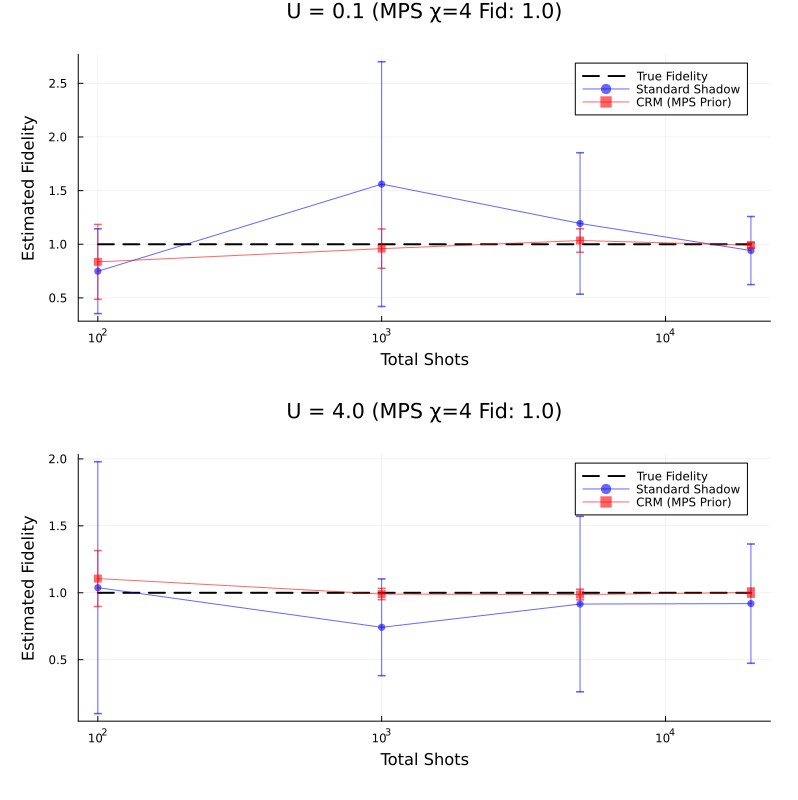

In [8]:
using LinearAlgebra
using Printf
using Statistics
using Plots
using Dates
using ITensors
using ITensorMPS

# ==========================================
# 1. ハミルトニアンMPOの直接構築
# ==========================================
function build_hubbard_mpo(sites, t_L, t_S, U, mu)
    os = OpSum()
    
    function add_hopping!(os, i, j, t)
        min_idx, max_idx = min(i, j), max(i, j)
        term1 = Any[-t, "S-", max_idx]
        for k in (min_idx+1):(max_idx-1); push!(term1, "Z", k); end
        push!(term1, "S+", min_idx)
        os += tuple(term1...)
        
        term2 = Any[-t, "S+", max_idx]
        for k in (min_idx+1):(max_idx-1); push!(term2, "Z", k); end
        push!(term2, "S-", min_idx)
        os += tuple(term2...)
    end
    
    edges_L = [(1, 3), (2, 4), (5, 7), (6, 8), (1, 7), (2, 8)]
    for (i, j) in edges_L; add_hopping!(os, i, j, t_L); end
    
    edges_S = [(3, 5), (4, 6)]
    for (i, j) in edges_S; add_hopping!(os, i, j, t_S); end
    
    for i in 1:2:7
        j = i + 1
        os += U, "S-", i, "S+", i, "S-", j, "S+", j
    end
    
    for i in 1:8
        os += -mu, "S-", i, "S+", i
    end
    
    return MPO(os, sites)
end

# ==========================================
# 2. DMRGによる基底状態の探索 (SVD圧縮対応)
# ==========================================
function get_ground_state_mps(H_mpo, sites, max_chi::Int)
    init_state = ["Up", "Dn", "Up", "Dn", "Up", "Dn", "Up", "Dn"]
    psi0 = randomMPS(sites, init_state, linkdims=2)
    
    nsweeps = 8
    dim1 = min(10, max_chi)
    dim2 = min(20, max_chi)
    maxdim = [dim1, dim2, max_chi, max_chi, max_chi, max_chi, max_chi, max_chi]
    cutoff = 1E-10
    
    energy, psi_mps = dmrg(H_mpo, psi0; nsweeps, maxdim, cutoff, outputlevel=0)
    return psi_mps
end

function mps_to_vec(psi_mps, sites)
    T = prod(psi_mps)
    vec_multi = Array(T, sites...)
    vec_out = reshape(vec_multi, 256)
    vec_out ./= norm(vec_out)
    return real.(vec_out)
end

# ==========================================
# 3. 高速化シャドウサンプリング
# ==========================================
function get_measurement_probs(state_vec, u_list)
    U_global = ones(ComplexF64, 1, 1)
    for i in 8:-1:1; U_global = kron(u_list[i], U_global); end
    return abs2.(U_global * state_vec)
end

function sample_index(probs)
    r, cp = rand(), 0.0
    for i in 1:256
        cp += probs[i]
        if r <= cp; return i - 1; end
    end
    return 255
end

function build_snapshot(idx, u_list)
    bits = reverse(digits(idx, base=2, pad=8))
    I2 = ComplexF64[1 0; 0 1]
    rho = ones(ComplexF64, 1, 1)
    for i in 8:-1:1
        u, b = u_list[i], bits[i]
        s_b = (b == 0) ? [1.0, 0.0] : [0.0, 1.0]
        rho = kron(3.0 .* (u' * (s_b * s_b') * u) - I2, rho)
    end
    return rho
end

# ==========================================
# 4. メイン実行部
# ==========================================
function main()
    # グラフ描画エンジンを強制リセット
    Plots.gr()
    
    # --- 0. 保存先の準備 (関数内に移動して安全化) ---
    desktop_path = joinpath(homedir(), "Desktop", "GraphResults_Hubbard_CRM_DMRG")
    mkpath(desktop_path)
    println("▶ 画像の保存先: $desktop_path")

    t_L, t_S = 1.0, 1.0
    settings_list = [(nu=10, nm=10), (nu=20, nm=50), (nu=50, nm=100), (nu=100, nm=200)]
    n_repeat = 15
    U_list = [0.1, 4.0]
    chi = 4 
    
    total_shots_list = [s.nu * s.nm for s in settings_list]
    plots_array = []
    
    println("\n=== Starting CRM Simulation with SVD Truncated Prior (χ=$chi) ===")
    sites = siteinds("S=1/2", 8)
    
    for U in U_list
        @printf("\n>> Processing U = %.1f ...\n", U)
        mu = U / 2.0
        
        H_mpo = build_hubbard_mpo(sites, t_L, t_S, U, mu)
        
        # 1. 真の基底状態を取得 (χ=100)
        psi_true = get_ground_state_mps(H_mpo, sites, 100)
        vec_true = mps_to_vec(psi_true, sites)
        
        # 2. 真の状態をSVD圧縮して近似状態を作る
        psi_approx = copy(psi_true)
        truncate!(psi_approx; maxdim=chi, cutoff=1E-10)
        vec_mps = mps_to_vec(psi_approx, sites)
        
        # Fidelityの確認
        true_fid = abs(dot(vec_true, vec_mps))^2
        @printf("  -> MPS Prior Fidelity (χ=%d): %.4f\n", chi, true_fid)
        
        m_std, e_std, m_crm, e_crm = Float64[], Float64[], Float64[], Float64[]
        
        for (nu, nm) in settings_list
            tmp_std, tmp_crm = Float64[], Float64[]
            for rep in 1:n_repeat
                v_std_nu, v_crm_nu = 0.0, 0.0
                for r in 1:nu
                    u_l = [rand([ComplexF64[1 0; 0 1], [1 1; 1 -1]/sqrt(2), [1 -im; 1 im]/sqrt(2)]) for _ in 1:8]
                    p_true = get_measurement_probs(vec_true, u_l)
                    p_mps = get_measurement_probs(vec_mps, u_l)
                    
                    s_true, s_mps = 0.0, 0.0
                    for m in 1:nm
                        s_true += real(vec_mps' * build_snapshot(sample_index(p_true), u_l) * vec_mps)
                        s_mps += real(vec_mps' * build_snapshot(sample_index(p_mps), u_l) * vec_mps)
                    end
                    v_std_nu += s_true / nm
                    v_crm_nu += (s_true - s_mps) / nm
                end
                push!(tmp_std, v_std_nu / nu)
                push!(tmp_crm, (v_crm_nu / nu) + 1.0)
            end
            push!(m_std, mean(tmp_std)); push!(e_std, std(tmp_std))
            push!(m_crm, mean(tmp_crm)); push!(e_crm, std(tmp_crm))
        end
        
        p = plot(total_shots_list, fill(true_fid, length(total_shots_list)), 
                 label="True Fidelity", lw=2, color=:black, linestyle=:dash, xscale=:log10)
        plot!(p, total_shots_list, m_std, yerror=e_std, label="Standard Shadow", marker=:circle, color=:blue, msc=:blue, alpha=0.6)
        plot!(p, total_shots_list, m_crm, yerror=e_crm, label="CRM (MPS Prior)", marker=:square, color=:red, msc=:red, alpha=0.6)
        title!(p, "U = $U (MPS χ=$chi Fid: $(round(true_fid, digits=3)))")
        xlabel!(p, "Total Shots")
        ylabel!(p, "Estimated Fidelity")
        push!(plots_array, p)
    end
    
    println("\n▶ 全てのシミュレーションが完了しました。グラフを結合・保存します...")
    
    try
        final_plot = plot(plots_array..., layout=(2, 1), size=(800, 800), margin=5Plots.mm)
        
        current_time = now()
        timestamp_str = Dates.format(current_time, "yyyy-mm-dd_HHMMSS")
        file_name = "crm_dmrg_result_$(timestamp_str).png"
        save_full_path = joinpath(desktop_path, file_name)
        
        savefig(final_plot, save_full_path)
        println("\n✅ 【成功】画像が正常に保存されました: $file_name")
        display(final_plot) # Jupyter上にも表示する
    catch e
        println("\n❌ 【エラー】画像の保存中に問題が発生しました！")
        println(e)
    end
end

# 実行
main()

# ハバードバージョン  

In [10]:
using ITensors
using Printf

function main()
    # 1. パラメータの設定
    N = 4             # サイト数
    t_L = 1.0         # 長い結合のホッピング
    t_S = 1.0         # 短い結合のホッピング
    U = 4.0           # 局所電子間反発
    mu = U / 2.0      # 化学ポテンシャル (ハーフフィリング条件)

    # 2. サイト（物理空間）の定義
    sites = siteinds("Electron", N; conserve_qns=true)

    # 3. ハミルトニアンの構築 (OpSum)
    os = OpSum()

    # ホッピング項 (t_L, t_S) の追加
    edges = [(1, 2, t_L), (2, 3, t_S), (3, 4, t_L), (4, 1, t_L)]
    
    for (i, j, t) in edges
        for s in ["up", "dn"]
            # ★修正箇所: "Cu$s" を "C$s" に変更 ("Cup", "Cdn" が正しく生成されます)
            os += -t, "Cdag$s", i, "C$s", j
            os += -t, "Cdag$s", j, "C$s", i
        end
    end

    # 相互作用項 (U) と化学ポテンシャル項 (mu) の追加
    for i in 1:N
        os += U, "Nup", i, "Ndn", i
        os += -mu, "Nup", i
        os += -mu, "Ndn", i
    end

    # 行列積演算子 (MPO) へ変換
    H = MPO(os, sites)

    # 4. 初期状態 (MPS) の準備
    # ハーフフィリング（アップ2個、ダウン2個）のセクターを指定
    state = ["Up", "Dn", "Up", "Dn"] 
    psi0 = random_mps(sites, state; linkdims=10)

    # 5. DMRGの実行設定
    nsweeps = 5
    maxdim = [10, 20, 100, 100]
    cutoff = [1E-10]

    println("=== Starting DMRG for 4-site Hubbard Model ===")
    energy, psi = dmrg(H, psi0; nsweeps, maxdim, cutoff)

    @printf("\nGround State Energy: %.10f\n", energy)
    
    # 期待値の計算
    println("\nParticle Occupancy per site:")
    for j in 1:N
        n_up = expect(psi, "Nup"; sites=j)
        n_dn = expect(psi, "Ndn"; sites=j)
        @printf("  Site %d: <Nup> = %.4f, <Ndn> = %.4f (Total = %.4f)\n", j, n_up, n_dn, n_up+n_dn)
    end
end

main()

=== Starting DMRG for 4-site Hubbard Model ===
After sweep 1 energy=-9.947127840016824  maxlinkdim=10 maxerr=1.26E-02 time=15.439
After sweep 2 energy=-10.08679108299504  maxlinkdim=16 maxerr=1.15E-15 time=0.021
After sweep 3 energy=-10.101395980645005  maxlinkdim=16 maxerr=1.10E-15 time=0.029
After sweep 4 energy=-10.10263701430556  maxlinkdim=16 maxerr=9.87E-16 time=0.067
After sweep 5 energy=-10.102739263636211  maxlinkdim=16 maxerr=6.35E-16 time=0.025

Ground State Energy: -10.1027392636

Particle Occupancy per site:
  Site 1: <Nup> = 0.4962, <Ndn> = 0.5038 (Total = 1.0000)
  Site 2: <Nup> = 0.5038, <Ndn> = 0.4962 (Total = 1.0000)
  Site 3: <Nup> = 0.4962, <Ndn> = 0.5038 (Total = 1.0000)
  Site 4: <Nup> = 0.5038, <Ndn> = 0.4962 (Total = 1.0000)


In [13]:
using LinearAlgebra
using Printf
using Statistics
using Plots
using Dates
using ProgressMeter
using ITensors # ★追加

# --- 0. 保存先の準備 ---
desktop_path = joinpath(homedir(), "Desktop", "GraphResults_Hubbard_CRM_DMRG")
mkpath(desktop_path)
println("Images will be saved to: $desktop_path")

# ==========================================
# 1. ハミルトニアンと演算子の構築関数
# ==========================================
function make_matrix(ops...)
    r = ones(1, 1)
    for op in reverse(ops)
        r = kron(op, r)
    end
    return r
end

function get_creation_ops()
    cdag = [0.0 0.0; 1.0 0.0]
    I2   = [1.0 0.0; 0.0 1.0]
    F_op = [1.0 0.0; 0.0 -1.0]
    Cdag = Dict{String, Matrix{Float64}}()
    Cdag["1u"] = make_matrix(I2, I2, I2, I2, I2, I2, I2, cdag)
    Cdag["1d"] = make_matrix(I2, I2, I2, I2, I2, I2, cdag, F_op)
    Cdag["2u"] = make_matrix(I2, I2, I2, I2, I2, cdag, F_op, F_op)
    Cdag["2d"] = make_matrix(I2, I2, I2, I2, cdag, F_op, F_op, F_op)
    Cdag["3u"] = make_matrix(I2, I2, I2, cdag, F_op, F_op, F_op, F_op)
    Cdag["3d"] = make_matrix(I2, I2, cdag, F_op, F_op, F_op, F_op, F_op)
    Cdag["4u"] = make_matrix(I2, cdag, F_op, F_op, F_op, F_op, F_op, F_op)
    Cdag["4d"] = make_matrix(cdag, F_op, F_op, F_op, F_op, F_op, F_op, F_op)
    return Cdag
end

function build_hamiltonian(t_L, t_S, U, mu)
    Cdag = get_creation_ops()
    C_op = Dict(k => v' for (k, v) in Cdag)
    N_op = Dict(k => Cdag[k] * C_op[k] for k in keys(Cdag))
    hamil = zeros(Float64, 256, 256)
    edges_L = [("1u", "2u"), ("1d", "2d"), ("2u", "1u"), ("2d", "1d"), 
               ("3u", "4u"), ("3d", "4d"), ("4u", "3u"), ("4d", "3d"), 
               ("4u", "1u"), ("4d", "1d"), ("1u", "4u"), ("1d", "4d")]
    for (k1, k2) in edges_L; hamil .+= -t_L .* (Cdag[k1] * C_op[k2]); end
    edges_S = [("2u", "3u"), ("2d", "3d"), ("3u", "2u"), ("3d", "2d")]
    for (k1, k2) in edges_S; hamil .+= -t_S .* (Cdag[k1] * C_op[k2]); end
    pairs_U = [("1u", "1d"), ("2u", "2d"), ("3u", "3d"), ("4u", "4d")]
    for (k1, k2) in pairs_U; hamil .+= U .* (N_op[k1] * N_op[k2]); end
    for op in values(N_op); hamil .+= -mu .* op; end
    return hamil
end

function get_particle_number_ops()
    Cdag = get_creation_ops()
    C_op = Dict(k => v' for (k, v) in Cdag)
    N_op = Dict(k => Cdag[k] * C_op[k] for k in keys(Cdag))
    N_up_op = zeros(Float64, 256, 256)
    N_dn_op = zeros(Float64, 256, 256)
    for i in 1:4
        N_up_op .+= N_op["$(i)u"]
        N_dn_op .+= N_op["$(i)d"]
    end
    return N_up_op, N_dn_op
end

function solve_ed_state_vector(hamil::Matrix{Float64})
    F = eigen(Symmetric(hamil))
    return F.vectors[:, 1]
end

# ==========================================
# 2. ★新規: DMRGによる事前状態の構築とベクトル変換
# ==========================================
function get_dmrg_state_vector(t_L, t_S, U, mu, N_up, N_dn, max_bond_dim)
    # 符号問題を回避するため、Electronサイトではなく8つのFermionサイトとして構築
    sites = siteinds("Fermion", 8; conserve_qns=true)
    
    # 手組みクロネッカー積の順序 (1u, 1d, 2u, 2d, 3u, 3d, 4u, 4d) とITensorサイト番号を一致させる
    s_idx(site, spin) = 2 * (site - 1) + (spin == "u" ? 1 : 2)
    
    os = OpSum()
    
    # ホッピング項
    edges = [(1, 2, t_L), (2, 3, t_S), (3, 4, t_L), (4, 1, t_L)]
    for (i, j, t) in edges
        for spin in ["u", "d"]
            idx_i = s_idx(i, spin)
            idx_j = s_idx(j, spin)
            os += -t, "Cdag", idx_i, "C", idx_j
            os += -t, "Cdag", idx_j, "C", idx_i
        end
    end
    
    # 相互作用項と化学ポテンシャル
    for i in 1:4
        idx_u = s_idx(i, "u")
        idx_d = s_idx(i, "d")
        os += U, "N", idx_u, "N", idx_d
        os += -mu, "N", idx_u
        os += -mu, "N", idx_d
    end
    
    H = MPO(os, sites)
    
    # 初期状態に粒子数を割り振る
    state = ["Emp" for _ in 1:8]
    up_placed, dn_placed = 0, 0
    for i in 1:4
        if up_placed < N_up; state[s_idx(i, "u")] = "Occ"; up_placed += 1; end
        if dn_placed < N_dn; state[s_idx(i, "d")] = "Occ"; dn_placed += 1; end
    end
    
    psi0 = random_mps(sites, state; linkdims=max_bond_dim)
    
    nsweeps = 5
    maxdim = [10, 20, max_bond_dim]
    cutoff = [1E-10]
    
    # DMRGを実行 (ログ出力を抑えるために outputlevel=0)
    energy, psi = dmrg(H, psi0; nsweeps, maxdim, cutoff, outputlevel=0)
    
    # テンソルをすべて縮約し、元のクロネッカー積の順序に従って配列に変換
    ITensors.disable_warn_order()
    psi_tensor = prod(psi)
    arr = Array(psi_tensor, sites[1], sites[2], sites[3], sites[4], sites[5], sites[6], sites[7], sites[8])
    
    return vec(arr)
end

# ==========================================
# 3. 高速化シャドウサンプリング
# ==========================================
function get_measurement_probs(state_vec, u_list)
    U_global = ones(ComplexF64, 1, 1)
    for i in 8:-1:1; U_global = kron(u_list[i], U_global); end
    return abs2.(U_global * state_vec)
end

function sample_index(probs)
    r, cp = rand(), 0.0
    for i in 1:256
        cp += probs[i]
        if r <= cp; return i - 1; end
    end
    return 255
end

function build_snapshot(idx, u_list)
    bits = reverse(digits(idx, base=2, pad=8))
    I2 = ComplexF64[1 0; 0 1]
    rho = ones(ComplexF64, 1, 1)
    for i in 8:-1:1
        u, b = u_list[i], bits[i]
        s_b = (b == 0) ? [1.0, 0.0] : [0.0, 1.0]
        rho = kron(3.0 .* (u' * (s_b * s_b') * u) - I2, rho)
    end
    return rho
end

# ==========================================
# 4. メイン実行部
# ==========================================
function main()
    t_L, t_S = 1.0, 1.0
    settings_list = [(nu=10, nm=10), (nu=20, nm=50), (nu=50, nm=100), (nu=100, nm=200)]
    n_repeat = 20
    U_list = [0.1, 4.0]
    
    total_shots_list = [s.nu * s.nm for s in settings_list]
    plots_array = []
    
    N_up_op, N_dn_op = get_particle_number_ops()
    
    # ★ ログファイルの準備
    timestamp_str = Dates.format(now(), "yyyy-mm-dd_HHMMSS")
    log_filename = joinpath(desktop_path, "crm_dmrg_log_$(timestamp_str).txt")
    
    open(log_filename, "w") do io
        println(io, "U, nu, nm, Standard_Error, CRM_Error, Improvement_Ratio")
    end
    
    println("=== Starting Dynamic CRM Simulation with DMRG Prior ===")
    println("Log file: $log_filename")
    
    for U in U_list
        @printf("\nProcessing U = %.1f ...\n", U)
        mu = 0.0
        
        hamil = build_hamiltonian(t_L, t_S, U, mu)
        vec_ed = solve_ed_state_vector(hamil)
        
        N_up_count = round(Int, real(vec_ed' * N_up_op * vec_ed))
        N_dn_count = round(Int, real(vec_ed' * N_dn_op * vec_ed))
        @printf("  -> ED determined particle sector: Up = %d, Dn = %d\n", N_up_count, N_dn_count)
        
        # ★ ここをHFからDMRGに置き換え
        max_bond_dim = 16 # DMRGの近似精度を制御 (4サイトなら16で事実上のFull-CI)
        vec_dmrg = get_dmrg_state_vector(t_L, t_S, U, mu, N_up_count, N_dn_count, max_bond_dim)
        
        true_fid = abs(dot(vec_ed, vec_dmrg))^2
        @printf("  -> DMRG Prior True Fidelity: %.6f\n", true_fid)
        
        m_std, e_std, m_crm, e_crm = Float64[], Float64[], Float64[], Float64[]
        
        for (nu, nm) in settings_list
            tmp_std, tmp_crm = Float64[], Float64[]
            @showprogress 1 "  Simulating (nu=$(lpad(nu,3)), nm=$(lpad(nm,3))) : " for rep in 1:n_repeat
                v_std_nu, v_crm_nu = 0.0, 0.0
                for r in 1:nu
                    u_l = [rand([ComplexF64[1 0; 0 1], [1 1; 1 -1]/sqrt(2), [1 -im; 1 im]/sqrt(2)]) for _ in 1:8]
                    p_ed = get_measurement_probs(vec_ed, u_l)
                    p_dmrg = get_measurement_probs(vec_dmrg, u_l)
                    
                    s_ed, s_dmrg = 0.0, 0.0
                    for m in 1:nm
                        s_ed += real(vec_dmrg' * build_snapshot(sample_index(p_ed), u_l) * vec_dmrg)
                        s_dmrg += real(vec_dmrg' * build_snapshot(sample_index(p_dmrg), u_l) * vec_dmrg)
                    end
                    v_std_nu += s_ed / nm
                    v_crm_nu += (s_ed - s_dmrg) / nm
                end
                push!(tmp_std, v_std_nu / nu)
                push!(tmp_crm, (v_crm_nu / nu) + 1.0)
            end
            
            val_e_std = std(tmp_std)
            val_e_crm = std(tmp_crm)
            push!(m_std, mean(tmp_std)); push!(e_std, val_e_std)
            push!(m_crm, mean(tmp_crm)); push!(e_crm, val_e_crm)
            
            ratio = val_e_std / (val_e_crm + 1e-12)
            @printf("    => Standard誤差: %.6f | CRM誤差: %.6f (約 %.1f 倍の改善)\n", val_e_std, val_e_crm, ratio)
            
            # ログの記録
            open(log_filename, "a") do io
                @printf(io, "%.1f, %d, %d, %.6f, %.6f, %.2f\n", U, nu, nm, val_e_std, val_e_crm, ratio)
            end
        end
        
        p = plot(total_shots_list, fill(true_fid, length(total_shots_list)), 
                 label="True Fidelity", lw=2, color=:black, linestyle=:dash, xscale=:log10)
        plot!(p, total_shots_list, m_std, yerror=e_std, label="Standard Shadow", marker=:circle, color=:blue, msc=:blue, alpha=0.6)
        plot!(p, total_shots_list, m_crm, yerror=e_crm, label="CRM (DMRG Prior)", marker=:square, color=:red, msc=:red, alpha=0.6)
        title!(p, "U = $U (DMRG Fid: $(round(true_fid, digits=4)))")
        xlabel!(p, "Total Shots")
        ylabel!(p, "Estimated Fidelity")
        push!(plots_array, p)
    end
    
    final_plot = plot(plots_array..., layout=(1, 2), size=(900, 400), margin=5Plots.mm)

    println("\nプロットを生成中...")
    file_name = "crm_dmrg_dynamic_mu=0_result_$(timestamp_str).png"

    save_full_path = joinpath(desktop_path, file_name)
    savefig(final_plot, save_full_path)
    println("完了しました。画像を確認してください: $file_name")
end

main()

Images will be saved to: /Users/tatsuyamahiroshitaira/Desktop/GraphResults_Hubbard_CRM_DMRG
=== Starting Dynamic CRM Simulation with DMRG Prior ===
Log file: /Users/tatsuyamahiroshitaira/Desktop/GraphResults_Hubbard_CRM_DMRG/crm_dmrg_log_2026-04-27_143738.txt

Processing U = 0.1 ...
  -> ED determined particle sector: Up = 1, Dn = 1
  -> DMRG Prior True Fidelity: 1.000000


┌ Warning: MPS center bond dimension is less than requested (you requested 16, but in practice it is 6. This is likely due to technicalities of truncating quantum number sectors.
└ @ ITensorMPS /Users/tatsuyamahiroshitaira/.julia/packages/ITensorMPS/AQY99/src/mps.jl:153
  Simulating (nu= 10, nm= 10) : 100%|███████████████████| Time: 0:00:03


    => Standard誤差: 0.563567 | CRM誤差: 0.387833 (約 1.5 倍の改善)


  Simulating (nu= 20, nm= 50) : 100%|███████████████████| Time: 0:00:32


    => Standard誤差: 0.239458 | CRM誤差: 0.110128 (約 2.2 倍の改善)


...

    => Standard誤差: 0.255568 | CRM誤差: 0.103676 (約 2.5 倍の改善)


  Simulating (nu= 50, nm=100) : 100%|███████████████████| Time: 0:02:30


    => Standard誤差: 0.163672 | CRM誤差: 0.056431 (約 2.9 倍の改善)


  Simulating (nu=100, nm=200) : 100%|███████████████████| Time: 0:10:35


    => Standard誤差: 0.110312 | CRM誤差: 0.028946 (約 3.8 倍の改善)

プロットを生成中...
完了しました。画像を確認してください: crm_dmrg_dynamic_mu=0_result_2026-04-27_143738.png
